In [44]:
#TASK 1 starts

import pandas as pd 
df=pd.read_csv(r"C:\Users\dell\Downloads\Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [8]:
df.shape

(545, 13)

In [10]:
#Target
y=df['price']
#Features
x=df.drop(columns=['price'])

In [12]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
# There are no missing values in any column that need to be filled or dropped.

In [43]:
#TASK 2 starts

df.duplicated().sum()

np.int64(0)

In [19]:
df_encoded= pd.get_dummies(df, drop_first=True, dtype= int)
df_encoded.head(10)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
5,10850000,7500,3,3,1,2,1,0,1,0,1,1,1,0
6,10150000,8580,4,3,4,2,1,0,0,0,1,1,1,0
7,10150000,16200,5,3,2,0,1,0,0,0,0,0,0,1
8,9870000,8100,4,1,2,2,1,1,1,0,1,1,0,0
9,9800000,5750,3,2,4,1,1,1,0,0,1,1,0,1


In [20]:
#Target
y=df_encoded['price']
#Feature
x=df_encoded.drop(columns=['price'])

In [21]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    int64
 7   guestroom_yes                    545 non-null    int64
 8   basement_yes                     545 non-null    int64
 9   hotwaterheating_yes              545 non-null    int64
 10  airconditioning_yes              545 non-null    int64
 11  prefarea_yes                     545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    i

In [ ]:
# All 14 columns are relevant for house price prediction.

In [23]:
#TASK 3 starts

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
lr= LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr= lr.predict(x_test)

In [30]:
def evaluate(name, y_test, y_pred):
    mae= mean_absolute_error(y_test, y_pred)
    rmse= np.sqrt(mean_squared_error(y_test, y_pred))
    r2= r2_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"  MAE: {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²: {r2:.4f}")


In [29]:
evaluate("Linear Regression", y_test, y_pred_lr)


Linear Regression
  MAE  : 970,043.40
  RMSE : 1,324,506.96
  R²   : 0.6529


In [33]:
rf= RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf= rf.predict(x_test)

In [35]:
evaluate("Random Forest", y_test, y_pred_rf)


Random Forest
  MAE: 1,021,546.04
  RMSE: 1,400,565.97
  R²: 0.6119


In [ ]:
# On comparing, we can infer that the Linear Regression model outperformed the Random Forest model.

In [36]:
#TASK 4 

import matplotlib.pyplot as plt
import seaborn as sns


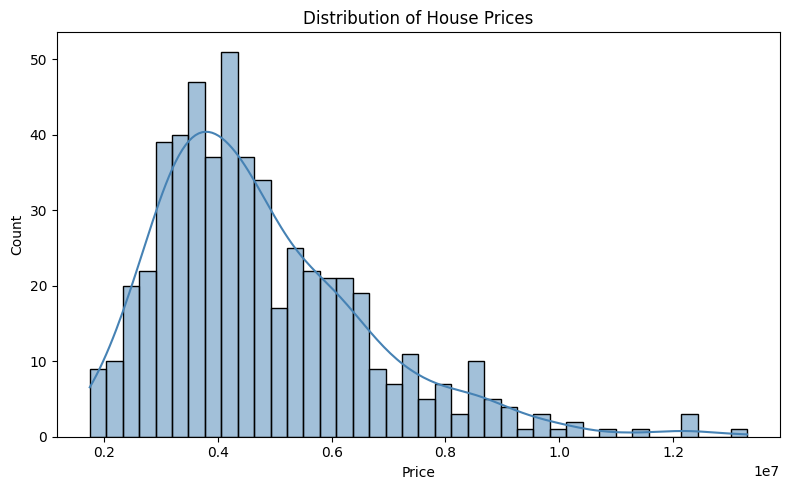

In [38]:
import os
os.makedirs('charts', exist_ok=True)

# Chart 1:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png')
plt.show()

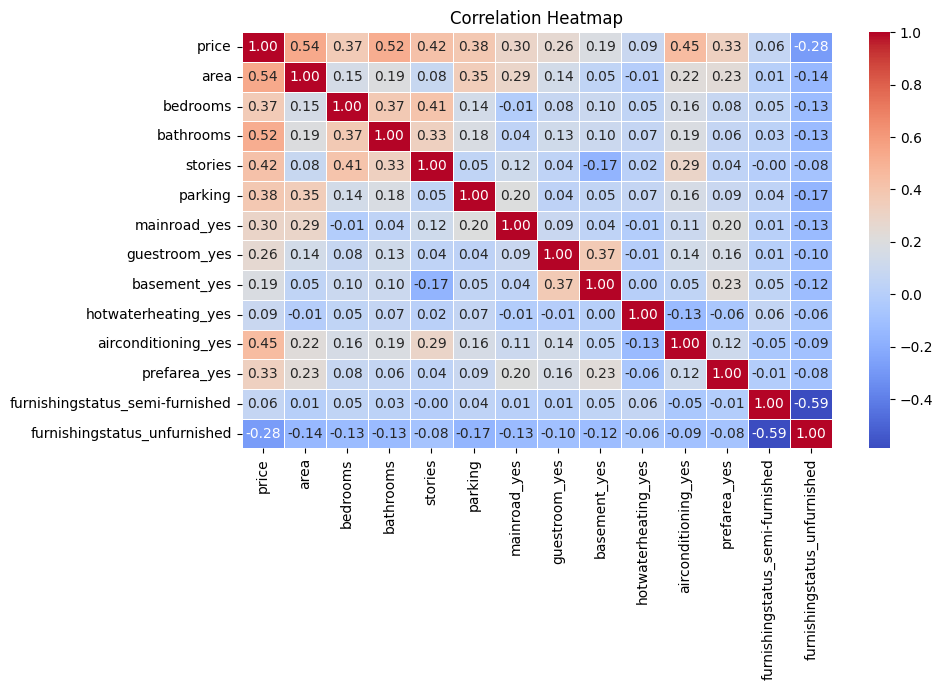

In [42]:
# Chart 2:
plt.figure(figsize=(10, 7))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png')
plt.show()

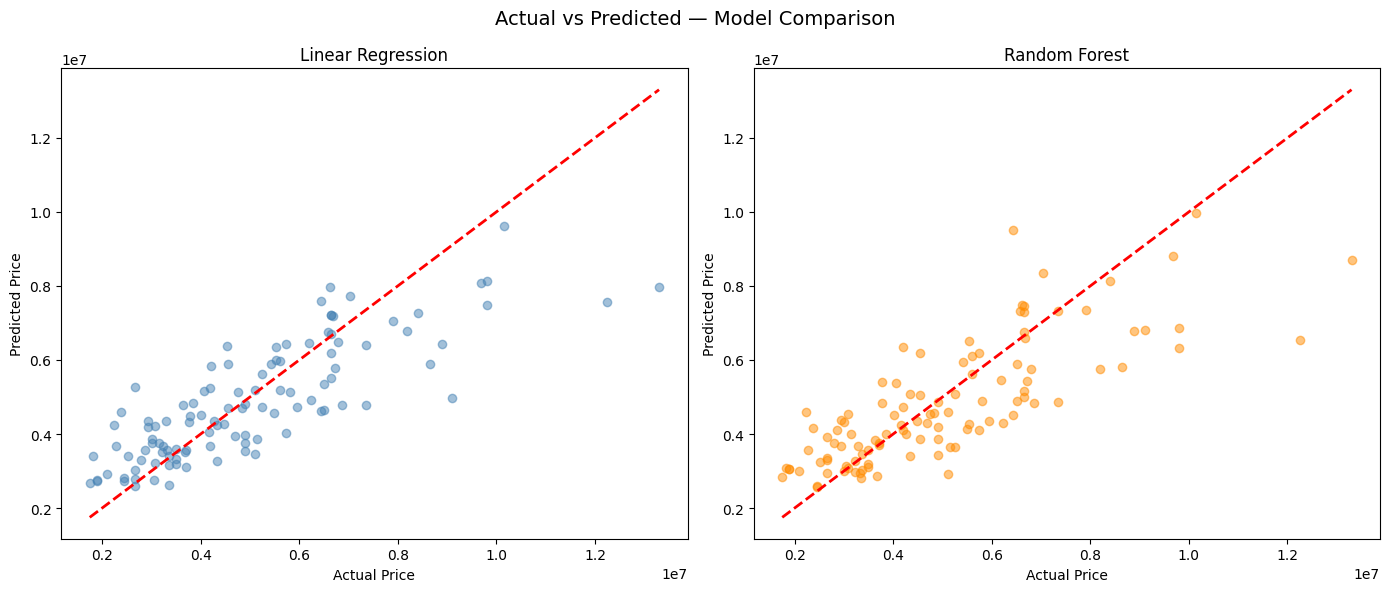

In [45]:
# Chart 3: Actual vs Predicted — Both Models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Linear Regression')

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.5, color='darkorange')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title('Random Forest')

plt.suptitle('Actual vs Predicted — Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png')
plt.show()

In [ ]:
#TASK 5
Which features influence house price the most?
Area (0.54) and bathrooms (0.52) have the strongest positive correlation with price, followed by air conditioning (0.45).
Whereas Unfurnished status (-0.28) actually pulls the price down the most negatively.

How accurate was your model (in plain terms)?
If a house actually costs ₹50 lakhs, the model would predict somewhere close to that not exact, but in the right range.
It works best for average-priced houses but gets less accurate for very expensive ones.

What surprised you in the data?
The fact that the number of bedrooms (0.37) mattered less than bathrooms (0.52) was unexpected.

One recommendation for a real estate business based on your findings
Focus investments on increasing liveable area and adding bathrooms, as these drive price the most and ensure properties are 
at least semi-furnished since unfurnished status clearly brings the price down significantly.    
